In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
from tensorflow.keras.layers import (
    Input, Embedding, Flatten, LSTM, Dense,
    Concatenate, Dropout,
    Reshape
)
from tensorflow.keras.models import Model

import gc

from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

2026-05-24 21:07:26.484065: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779656846.711855      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779656846.773119      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779656847.284634      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779656847.284668      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779656847.284671      23 computation_placer.cc:177] computation placer alr

In [2]:
# Check for GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Set TensorFlow to use only the first GPU
        tf.config.set_visible_devices(gpus[0], 'GPU')
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPU")
        print("GPU is available and configured.")
    except RuntimeError as e:
        # Visible devices must be set before GPUs have been initialized
        print(e)
else:
    print("No GPU devices found. Please ensure your Colab runtime type is set to 'GPU'.")

2 Physical GPUs, 1 Logical GPU
GPU is available and configured.


I0000 00:00:1779656873.560535      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5


In [3]:
train_df = pd.read_parquet('/kaggle/input/competitions/ts-forecasting/train.parquet')
test_df = pd.read_parquet('/kaggle/input/competitions/ts-forecasting/test.parquet')

# Drop weight column early to save memory (not used as feature)
train_weights = train_df['weight'].values  # keep if needed for evaluation
train_df.drop(columns=['weight'], inplace=True)

print(f"Full Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

# Subsample: keep complete entities (code + sub_code combos) to preserve full time evolution
# Get unique entity keys
entity_keys = train_df[['code', 'sub_code']].drop_duplicates()
print(f"Total unique (code, sub_code) entities: {len(entity_keys)}")

# Sample ~25% of entities (ensures manageable memory while keeping full temporal data)
np.random.seed(42)
sample_frac = 0.25
sampled_entities = entity_keys.sample(frac=sample_frac, random_state=42)
print(f"Sampled entities: {len(sampled_entities)} ({sample_frac*100:.0f}%)")

# Filter train_df to only include sampled entities
train_df = train_df.merge(sampled_entities, on=['code', 'sub_code'], how='inner').reset_index(drop=True)

# Verify all sub_categories and horizons are represented
print(f"\nSubsampled Train shape: {train_df.shape}")
print(f"Sub-categories in sample: {train_df['sub_category'].nunique()} / {test_df['sub_category'].nunique()}")
print(f"Horizons in sample: {sorted(train_df['horizon'].unique())}")
print(f"ts_index range: {train_df['ts_index'].min()} - {train_df['ts_index'].max()}")
print(f"\nTarget stats:\n{train_df['y_target'].describe()}")
print(f"\nMemory usage: {train_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

gc.collect()

Full Train shape: (5337414, 93)
Test shape: (1447107, 92)
Total unique (code, sub_code) entities: 1856
Sampled entities: 464 (25%)

Subsampled Train shape: (1366435, 93)
Sub-categories in sample: 5 / 5
Horizons in sample: [np.int32(1), np.int32(3), np.int32(10), np.int32(25)]
ts_index range: 1 - 3601

Target stats:
count    1.366435e+06
mean    -7.491421e-01
std      3.560880e+01
min     -1.468196e+03
25%     -1.358714e-01
50%     -6.048756e-04
75%      5.500799e-02
max      1.521666e+03
Name: y_target, dtype: float64

Memory usage: 1.31 GB


25

In [4]:
# Define feature columns
feature_cols = [c for c in train_df.columns if c.startswith('feature_')]
cat_cols = ['code', 'sub_code', 'sub_category', 'horizon']

print(f"Number of features: {len(feature_cols)}")
print(f"Categorical columns: {cat_cols}")

# Encode categorical variables (fit on train+test to handle all categories)
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([train_df[col], test_df[col]], axis=0)
    le.fit(combined)
    train_df[col + '_enc'] = le.transform(train_df[col]).astype(np.int32)
    test_df[col + '_enc'] = le.transform(test_df[col]).astype(np.int32)
    label_encoders[col] = le
    print(f"  {col}: {len(le.classes_)} unique values")

cat_enc_cols = [c + '_enc' for c in cat_cols]

# Drop original categorical string columns to save memory
train_df.drop(columns=cat_cols + ['id'], inplace=True)
test_ids = test_df['id'].values  # save for submission
test_df.drop(columns=cat_cols + ['id'], inplace=True)
gc.collect()
print(f"\nMemory after dropping strings: {train_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Number of features: 86
Categorical columns: ['code', 'sub_code', 'sub_category', 'horizon']
  code: 23 unique values
  sub_code: 199 unique values
  sub_category: 5 unique values
  horizon: 4 unique values

Memory after dropping strings: 0.97 GB


In [5]:
unique_counts = {col: len(label_encoders[col].classes_) for col in cat_cols}
unique_counts

{'code': 23, 'sub_code': 199, 'sub_category': 5, 'horizon': 4}

In [6]:
# Convert features to float32 and fill NaN in-place to save memory
for col in feature_cols:
    train_df[col] = train_df[col].fillna(0).astype(np.float32)
for col in feature_cols:
    test_df[col] = test_df[col].fillna(0).astype(np.float32)

gc.collect()

# Normalize numerical features (fit on train only, transform both)
# Use partial_fit approach to avoid creating full copy
scaler = StandardScaler()

# Fit scaler on train data
scaler.fit(train_df[feature_cols])

# Transform in chunks to reduce peak memory
chunk_size = 20  # process 20 columns at a time
for i in range(0, len(feature_cols), chunk_size):
    cols_chunk = feature_cols[i:i+chunk_size]
    idx = list(range(i, min(i+chunk_size, len(feature_cols))))
    train_df[cols_chunk] = ((train_df[cols_chunk].values - scaler.mean_[idx]) / scaler.scale_[idx]).astype(np.float32)
    test_df[cols_chunk] = ((test_df[cols_chunk].values - scaler.mean_[idx]) / scaler.scale_[idx]).astype(np.float32)

gc.collect()
print("Preprocessing complete.")
print(f"Train NaN count: {train_df[feature_cols].isnull().sum().sum()}")
print(f"Memory usage train: {train_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print(f"Memory usage test: {test_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Preprocessing complete.
Train NaN count: 0
Memory usage train: 0.51 GB
Memory usage test: 0.53 GB


In [7]:
# Split training data into train/validation using time-based split
# Use last portion of ts_index as validation (respects temporal order)
val_cutoff = int(train_df['ts_index'].max() * 0.85)  # ~85% for training
print(f"Validation cutoff ts_index: {val_cutoff}")

train_mask = train_df['ts_index'] <= val_cutoff
val_mask = train_df['ts_index'] > val_cutoff

train_split = train_df[train_mask].reset_index(drop=True)
val_split = train_df[val_mask].reset_index(drop=True)

print(f"Train split: {len(train_split)} rows (ts_index 1-{val_cutoff})")
print(f"Val split: {len(val_split)} rows (ts_index {val_cutoff+1}-{train_df['ts_index'].max()})")

Validation cutoff ts_index: 3060
Train split: 1126291 rows (ts_index 1-3060)
Val split: 240144 rows (ts_index 3061-3601)


In [8]:
train_feat_split = train_split[feature_cols].values.reshape((train_split.shape[0], 1, len(feature_cols)))
val_feat_split = val_split[feature_cols].values.reshape((val_split.shape[0], 1, len(feature_cols)))

train_feat_split.shape, val_feat_split.shape

((1126291, 1, 86), (240144, 1, 86))

In [9]:
train_dataset = tf.data.Dataset.from_tensor_slices(train_feat_split)
val_dataset = tf.data.Dataset.from_tensor_slices(val_feat_split)

In [10]:
cat_dataset = tf.data.Dataset.from_tensor_slices((
    tf.cast(train_split['code_enc'].values, tf.int32),
    tf.cast(train_split['sub_code_enc'].values, tf.int32),
    tf.cast(train_split['sub_category_enc'].values, tf.int32),
    tf.cast(train_split['horizon_enc'].values, tf.int32),
))

targets = tf.data.Dataset.from_tensor_slices(
    tf.cast(train_split['y_target'].values, tf.float32)
)

full_dataset = tf.data.Dataset.zip(((train_dataset, cat_dataset), targets)) \
    .shuffle(1024) \
    .batch(256) \
    .prefetch(tf.data.AUTOTUNE)

In [11]:
val_cat_dataset = tf.data.Dataset.from_tensor_slices((
    tf.cast(val_split['code_enc'].values, tf.int32),
    tf.cast(val_split['sub_code_enc'].values, tf.int32),
    tf.cast(val_split['sub_category_enc'].values, tf.int32),
    tf.cast(val_split['horizon_enc'].values, tf.int32),
))

val_targets = tf.data.Dataset.from_tensor_slices(
    tf.cast(val_split['y_target'].values, tf.float32)
)

val_full_dataset = tf.data.Dataset.zip(((val_dataset, val_cat_dataset), val_targets)) \
    .shuffle(1024) \
    .batch(256) \
    .prefetch(tf.data.AUTOTUNE)

In [12]:
print(f'Objetos eliminados: {gc.collect()}')

Objetos eliminados: 0


# Modelo

In [13]:
# Sequence input
seq_input = Input(shape=train_dataset.element_spec.shape, name="seq_input")
# seq_input = Flatten()(seq_input)

# code
code_input = Input(shape=(1,), name="code_input")
code_emb = Embedding(input_dim=unique_counts['code'], output_dim=len(feature_cols), name='code_embedding')(code_input)
# code_emb = Flatten()(code_emb)

# sub_code
sub_code_input = Input(shape=(1,), name="sub_code_input")
sub_code_emb = Embedding(input_dim=unique_counts['sub_code'], output_dim=len(feature_cols), name='sub_code_embedding')(sub_code_input)
# sub_code_emb = Flatten()(sub_code_emb)

# sub_category
sub_cat_input = Input(shape=(1,), name="sub_cat_input")
sub_cat_emb = Embedding(input_dim=unique_counts['sub_category'], output_dim=len(feature_cols), name='sub_category_embedding')(sub_cat_input)
# sub_cat_emb = Flatten()(sub_cat_emb)

# horizon
horizon_input = Input(shape=(1,), name="horizon_input")
horizon_emb = Embedding(input_dim=unique_counts['horizon'], output_dim=len(feature_cols),name='horizon_embedding')(horizon_input)
# horizon_emb = Flatten()(horizon_emb)

# Combine
x = Concatenate(axis=1, name='concat')([
    code_emb,
    sub_code_emb,
    sub_cat_emb,
    horizon_emb,
    seq_input
])

# x = Reshape((-1, 1))(x)
x = LSTM(256)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.2)(x)
x = Dense(64, activation="relu")(x)

output = Dense(1)(x)

model = Model(
    inputs=[
        seq_input,
        code_input,
        sub_code_input,
        sub_cat_input,
        horizon_input
    ],
    outputs=output
)

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="mae",
    metrics=['mse']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ code_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sub_code_input      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sub_cat_input       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ horizon_input       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ code_embedding      │ (None, 1, 86)     │      1,978 │ code_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sub_code_embedding  │ (None, 1, 86)     │     17,114 │ sub_code_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sub_category_embed… │ (None, 1, 86)     │        430 │ sub_cat_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ horizon_embedding   │ (None, 1, 86)     │        344 │ horizon_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq_input           │ (None, 1, 86)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 5, 86)     │          0 │ code_embedding[0… │
│ (Concatenate)       │                   │            │ sub_code_embeddi… │
│                     │                   │            │ sub_category_emb… │
│                     │                   │            │ horizon_embeddin… │
│                     │                   │            │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    351,232 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     32,896 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 412,315 (1.57 MB)

 Trainable params: 412,315 (1.57 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, verbose=1, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, verbose=1)

callbacks = [
    # early_stop,
    reduce_lr
]

In [15]:
history = model.fit(
    full_dataset,
  # [
  #   training_dataset,
  #   code_dataset,
  #   sub_code_dataset,
  #   sub_category_dataset,
  #   horizon_dataset
  # ],
  # y_train,
  validation_data=val_full_dataset,
  epochs=100,
  callbacks=callbacks
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['seq_input', 'code_input', 'sub_code_input', 'sub_cat_input', 'horizon_input']
Received: inputs=('Tensor(shape=(None, 1, 86))', ('Tensor(shape=(None,))', 'Tensor(shape=(None,))', 'Tensor(shape=(None,))', 'Tensor(shape=(None,))'))
  warnings.warn(msg)
I0000 00:00:1779656913.049052      68 cuda_dnn.cc:529] Loaded cuDNN version 91002


4400/4400 ━━━━━━━━━━━━━━━━━━━━ 40s 8ms/step - loss: 8.2542 - mse: 1680.5233 - val_loss: 5.4541 - val_mse: 674.0123 - learning_rate: 1.0000e-05
Epoch 2/100
4400/4400 ━━━━━━━━━━━━━━━━━━━━ 34s 8ms/step - loss: 8.2359 - mse: 1678.4078 - val_loss: 5.4457 - val_mse: 673.6202 - learning_rate: 1.0000e-05
Epoch 3/100
4400/4400 ━━━━━━━━━━━━━━━━━━━━ 35s 8ms/step - loss: 8.1870 - mse: 1671.9292 - val_loss: 5.4635 - val_mse: 674.7702 - learning_rate: 1.0000e-05
Epoch 4/100
4400/4400 ━━━━━━━━━━━━━━━━━━━━ 34s 8ms/step - loss: 8.1342 - mse: 1662.8035 - val_loss: 5.5106 - val_mse: 680.5885 - learning_rate: 1.0000e-05
Epoch 5/100
4400/4400 ━━━━━━━━━━━━━━━━━━━━ 34s 8ms/step - loss: 8.0886 - mse: 1653.0060 - val_loss: 5.5338 - val_mse: 686.7066 - learning_rate: 1.0000e-05
Epoch 6/100
4400/4400 ━━━━━━━━━━━━━━━━━━━━ 34s 8ms/step - loss: 8.0478 - mse: 1642.0840 - val_loss: 5.5533 - val_mse: 691.5142 - learning_rate: 1.0000e-05
Epoch 7/100
4400/4400 ━━━━━━━━━━━━━━━━━━━━ 34s 8ms/step - loss: 8.0061 - mse: 1629

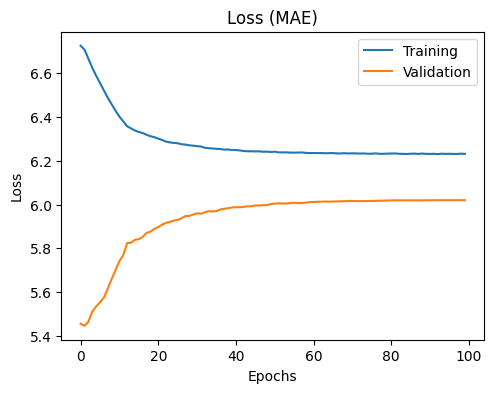

In [16]:
import matplotlib.pyplot as plt

# grafica de funcion de perdida y metricas
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.legend()
plt.title('Loss (MAE)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

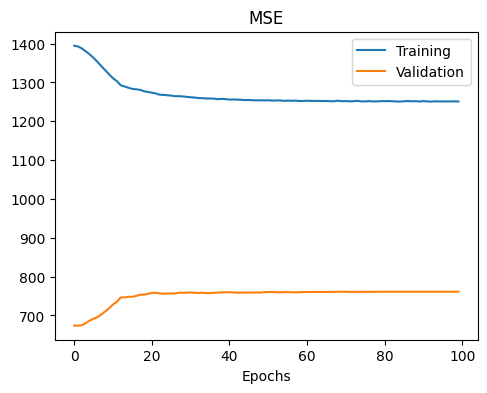

In [17]:
# grafica de funcion de perdida y metricas
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['mse'], label='Training')
plt.plot(history.history['val_mse'], label='Validation')
plt.legend()
plt.title('MSE')
plt.xlabel('Epochs')
plt.ylabel('')
plt.show()

In [18]:
model.save("model.keras")

In [19]:
import json
history_dict = history.history
# Save it to a file
with open("training_history.json", "w") as f:
    json.dump(history_dict, f)